In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "15_jun_logs.csv",
    engine='python',
    on_bad_lines='skip'
)

In [4]:
df.shape

(6656, 16)

In [5]:
df.columns

Index(['id', 'bat_current', 'bat_status', 'bat_volt', 'device_id',
       'json_value', 'load_current', 'load_status', 'load_volt',
       'metadata_date', 'pv_current', 'pv_volt', 'dod', 'ft', 'soc', 'wh'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6656 non-null   int64  
 1   bat_current    6656 non-null   float64
 2   bat_status     6656 non-null   object 
 3   bat_volt       6644 non-null   float64
 4   device_id      6656 non-null   int64  
 5   json_value     259 non-null    object 
 6   load_current   6656 non-null   float64
 7   load_status    6656 non-null   object 
 8   load_volt      6656 non-null   float64
 9   metadata_date  6656 non-null   object 
 10  pv_current     6656 non-null   float64
 11  pv_volt        6656 non-null   float64
 12  dod            289 non-null    float64
 13  ft             289 non-null    object 
 14  soc            277 non-null    float64
 15  wh             289 non-null    object 
dtypes: float64(8), int64(2), object(6)
memory usage: 832.1+ KB


In [7]:
df.isnull().sum()

id                  0
bat_current         0
bat_status          0
bat_volt           12
device_id           0
json_value       6397
load_current        0
load_status         0
load_volt           0
metadata_date       0
pv_current          0
pv_volt             0
dod              6367
ft               6367
soc              6379
wh               6367
dtype: int64

In [8]:
print(df['bat_status'].unique())
print(df['load_status'].unique())
print(df['ft'].unique())

['Charging' 'Normal' 'Full' 'Fault' 'Low']
['OFF' 'Off' 'ON']
[nan 'No Fault']


In [9]:
df['load_status'] = df['load_status'].str.upper()

In [10]:
df['load_status'].unique()

array(['OFF', 'ON'], dtype=object)

In [11]:
df['metadata_date'] = pd.to_datetime(df['metadata_date'])

In [12]:
df['hour'] = df['metadata_date'].dt.hour
df['day'] = df['metadata_date'].dt.day
df['month'] = df['metadata_date'].dt.month

In [13]:
df[['metadata_date','hour','day','month']].head()

,metadata_date,hour,day,month
0,2026-06-15 16:03:29.488,16,15,6
1,2026-06-15 16:03:29.635,16,15,6
2,2026-06-15 16:03:30.037,16,15,6
3,2026-06-15 16:03:30.377,16,15,6
4,2026-06-15 16:03:30.787,16,15,6


In [18]:
print(df['metadata_date'].min())
print(df['metadata_date'].max())

2026-06-15 16:03:29.488000
2026-06-15 17:01:57.608000


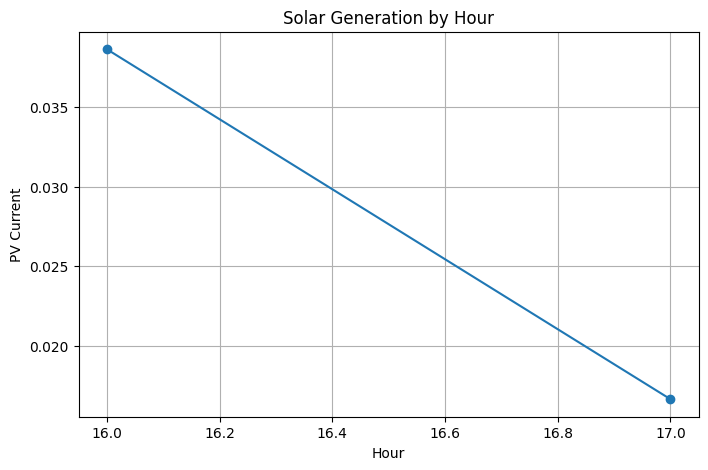

In [19]:
#Business Insight 1
#SOLAR GENERATION ANALYSIS (SHOWS AVG SOLAR CURRENT FOR EACH HOUR)
solar_hour = df.groupby('hour')['pv_current'].mean()

plt.figure(figsize=(8,5))
solar_hour.plot(marker='o')
plt.title('Solar Generation by Hour')
plt.xlabel('Hour')
plt.ylabel('PV Current')
plt.grid()
plt.show()

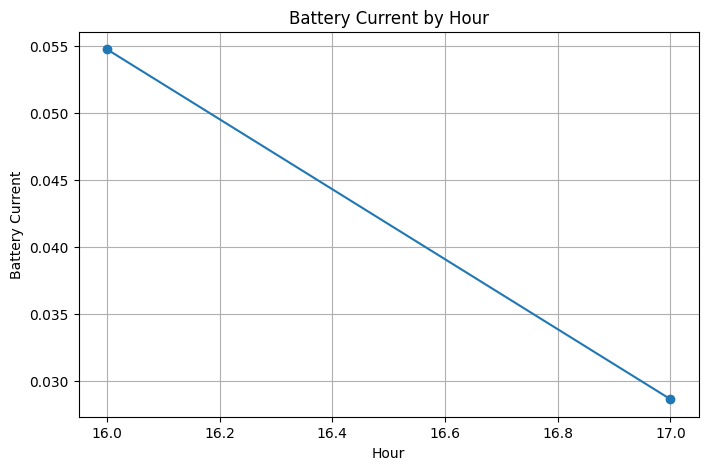

In [20]:
#Battery Insight 2
#BATTERY USAGE ANALYSIS
battery_hour = df.groupby('hour')['bat_current'].mean()

plt.figure(figsize=(8,5))
battery_hour.plot(marker='o')
plt.title('Battery Current by Hour')
plt.xlabel('Hour')
plt.ylabel('Battery Current')
plt.grid()
plt.show()

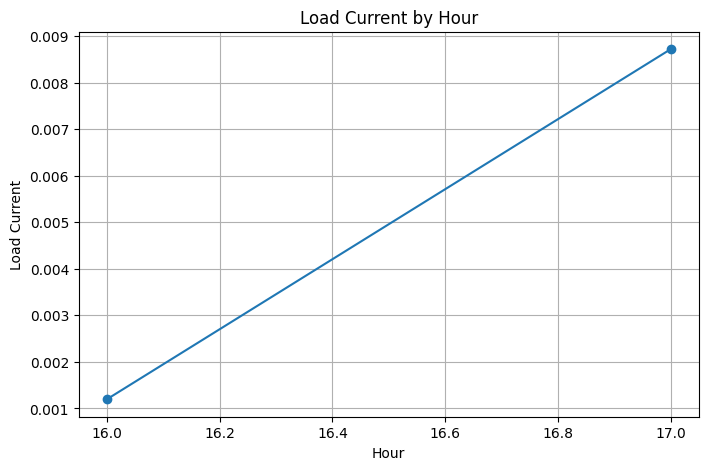

In [21]:
#BUSINESS INSIGHT 3
#Load Consumption Analysis
load_hour = df.groupby('hour')['load_current'].mean()

plt.figure(figsize=(8,5))
load_hour.plot(marker='o')
plt.title('Load Current by Hour')
plt.xlabel('Hour')
plt.ylabel('Load Current')
plt.grid()
plt.show()

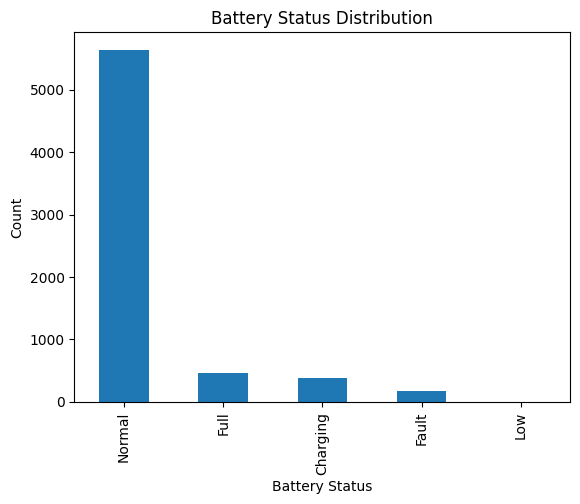

In [22]:
#BUSINESS INSIGHT 4
#Battery Status Distribution
df['bat_status'].value_counts().plot(kind='bar')

plt.title('Battery Status Distribution')
plt.xlabel('Battery Status')
plt.ylabel('Count')
plt.show()

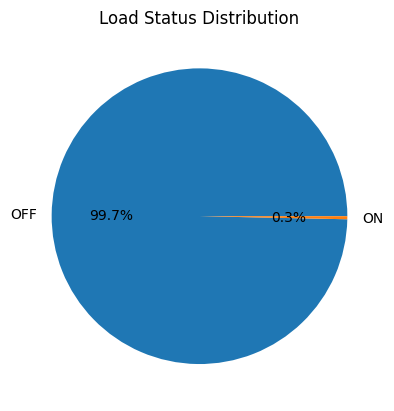

In [23]:
#BUSINESS INSIGHT 5
#Load Status Distribution
df['load_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Load Status Distribution')
plt.show()

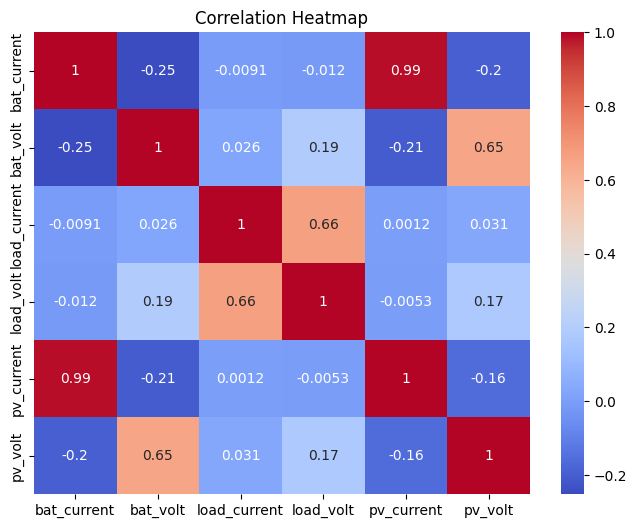

In [24]:
#BUSINESS INSIGHT 6
#Correlation Heatmap
num_cols = [
    'bat_current',
    'bat_volt',
    'load_current',
    'load_volt',
    'pv_current',
    'pv_volt'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [25]:
#7

print("Average PV Current :", round(df['pv_current'].mean(),2))
print("Maximum PV Current :", round(df['pv_current'].max(),2))

print("Average Battery Voltage :", round(df['bat_volt'].mean(),2))
print("Maximum Battery Voltage :", round(df['bat_volt'].max(),2))

print("Average Load Current :", round(df['load_current'].mean(),2))

print("Most Common Battery Status :",
      df['bat_status'].mode()[0])

print("Most Common Load Status :",
      df['load_status'].mode()[0])

Average PV Current : 0.04
Maximum PV Current : 3.8
Average Battery Voltage : 14.25
Maximum Battery Voltage : 29.2
Average Load Current : 0.0
Most Common Battery Status : Normal
Most Common Load Status : OFF


In [ ]:
Key Business Insights

1. The average solar panel current recorded during the monitoring period was 0.04 A.

2. The maximum solar panel current observed was 3.8 A, indicating periods of active solar power generation.

3. The battery voltage remained relatively stable with an average value of 14.25 V.

4. The maximum battery voltage recorded was 29.2 V.

5. The average load current was close to zero, indicating minimal load activity during the monitoring period.

6. The battery was predominantly operating in the "Normal" state.

7. The load remained mostly in the "OFF" state throughout the recorded period.

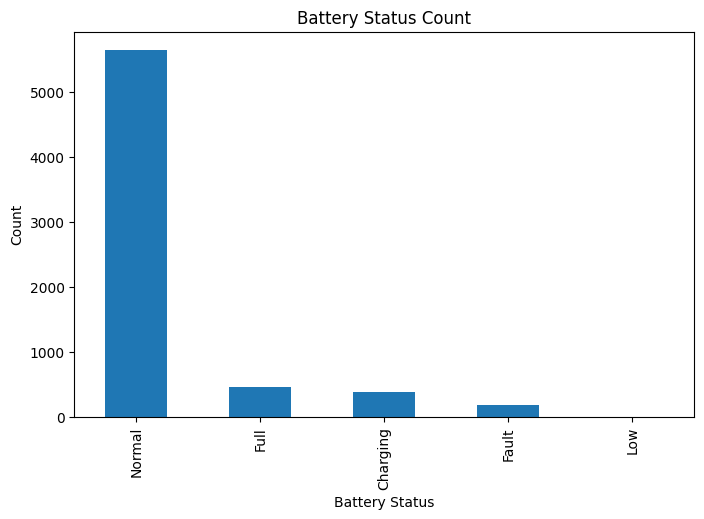

In [26]:
plt.figure(figsize=(8,5))
df['bat_status'].value_counts().plot(kind='bar')

plt.title('Battery Status Count')
plt.xlabel('Battery Status')
plt.ylabel('Count')

plt.show()

In [27]:
df['bat_status'].value_counts()

bat_status
Normal      5641
Full         454
Charging     382
Fault        178
Low            1
Name: count, dtype: int64

In [28]:
print(df['pv_current'].describe())

count    6656.000000
mean        0.037900
std         0.199648
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.800000
Name: pv_current, dtype: float64


In [29]:
df['bat_status'].value_counts(normalize=True) * 100

bat_status
Normal      84.750601
Full         6.820913
Charging     5.739183
Fault        2.674279
Low          0.015024
Name: proportion, dtype: float64

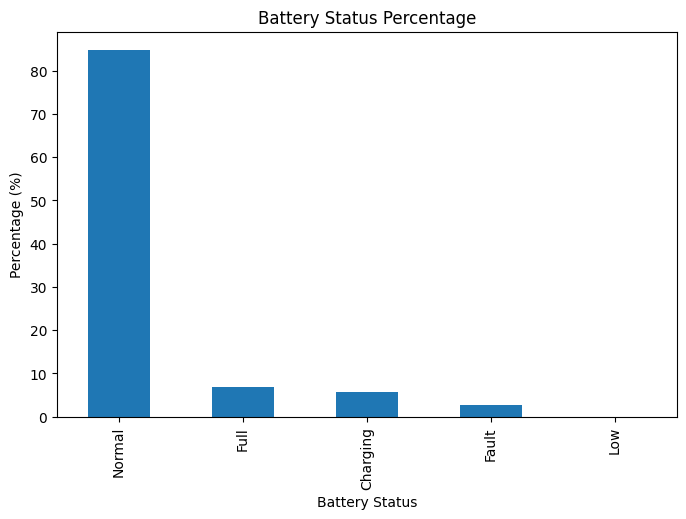

In [30]:
battery_percent = (
    df['bat_status']
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(8,5))
battery_percent.plot(kind='bar')

plt.title('Battery Status Percentage')
plt.xlabel('Battery Status')
plt.ylabel('Percentage (%)')

plt.show()

## Summary

1. The dataset contains battery, load and solar panel measurements.

2. The battery operated normally for most of the monitoring period.

3. Solar generation was limited during the recorded time window.

## Limitations

1. The dataset contains approximately one hour of monitoring data.

2. Long-term trends such as seasonal patterns and monthly energy generation cannot be analysed using the current dataset.

3. Some columns contain a large number of missing values, limiting detailed analysis.

4. Future forecasting models require larger historical datasets for better accuracy.

   